# Cargar librerias

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

# Leer Dataset

In [7]:
df = pd.read_csv('../DATA/PROCESSED/student_model_processed.csv')

# Entrenar modelo

In [8]:
# 1. Separar X e y - 5 VARIABLES
X = df[['G1', 'G2', 'failures', 'studytime', 'absences']]
y = df["risk_level"]

In [9]:
# 2. Encodear y
le = LabelEncoder()
y = le.fit_transform(y)


In [10]:
# 3. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalado

In [11]:
# 4. Escalar
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Creacion Modelo

In [12]:
# 5. Modelo
model = Sequential()
model.add(Dense(units=128, activation="relu"))
model.add(Dropout(0.3))
model.add(Dense(units=64, activation="relu"))
model.add(Dropout(0.4))
model.add(Dense(units=32, activation="relu"))
model.add(Dense(units=4, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenamiento del modelo

Epoch 1/55
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3928 - loss: 1.3535 - val_accuracy: 0.4976 - val_loss: 1.2868
Epoch 2/55
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4958 - loss: 1.2495 - val_accuracy: 0.4976 - val_loss: 1.2008
Epoch 3/55
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4982 - loss: 1.1882 - val_accuracy: 0.4976 - val_loss: 1.1511
Epoch 4/55
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5030 - loss: 1.1404 - val_accuracy: 0.4976 - val_loss: 1.1151
Epoch 5/55
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4982 - loss: 1.1056 - val_accuracy: 0.4976 - val_loss: 1.0834
Epoch 6/55
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5066 - loss: 1.0787 - val_accuracy: 0.4976 - val_loss: 1.0498
Epoch 7/55
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5138 - loss: 1.0591 - val_accuracy: 0.4928 - val_loss: 1.0127
Epoch 8/55
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5210 - loss: 1.0255 - val_accuracy: 0.5407 - val_l

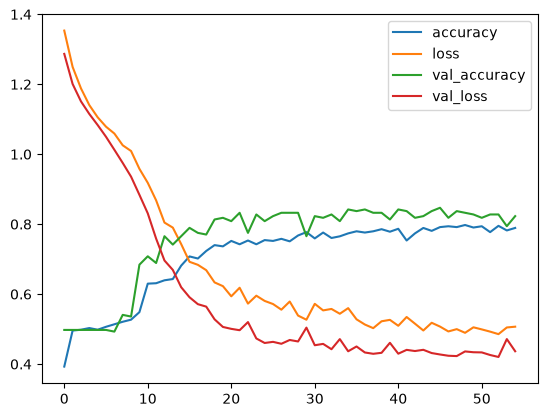

In [13]:
# 6. Entrenar
early_stop = EarlyStopping(monitor="val_loss", mode="min", patience=10)

model.fit(
    x=X_train,
    y=y_train,
    epochs=55,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

model_loss = pd.DataFrame(model.history.history)
model_loss.plot()

results = model.evaluate(X_test, y_test, verbose=0)
print(f"Loss: {results[0]:.4f}")
print(f"Accuracy: {results[1]:.4f}")

y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=le.classes_))



# Evaluacion del modelo

In [14]:
from sklearn.metrics import classification_report,confusion_matrix

# Prediccion sobre el conjunto test

In [15]:
predictions = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [16]:
y_test

array([1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 1, 1, 0, 3, 1, 1, 1, 2, 3, 1, 0,
       3, 0, 1, 1, 1, 3, 3, 2, 3, 1, 1, 3, 3, 1, 2, 3, 3, 2, 0, 0, 3, 1,
       1, 2, 0, 1, 3, 3, 0, 2, 1, 2, 2, 1, 3, 1, 1, 1, 3, 0, 3, 1, 1, 2,
       1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 3, 3, 1, 1, 2, 2, 1, 2, 1, 3, 1, 3,
       1, 3, 1, 3, 2, 3, 3, 3, 3, 1, 3, 3, 1, 1, 1, 3, 3, 2, 1, 1, 3, 1,
       1, 3, 1, 2, 1, 3, 3, 3, 1, 3, 3, 1, 2, 1, 3, 1, 3, 3, 3, 1, 1, 1,
       1, 1, 2, 3, 3, 1, 1, 2, 3, 1, 2, 0, 3, 1, 1, 3, 1, 1, 3, 1, 0, 2,
       1, 1, 3, 1, 0, 3, 1, 1, 2, 2, 1, 2, 1, 3, 1, 3, 1, 1, 1, 3, 1, 1,
       1, 0, 1, 0, 3, 1, 1, 1, 0, 1, 1, 2, 1, 1, 1, 2, 0, 2, 3, 1, 3, 1,
       0, 3, 3, 1, 1, 1, 1, 3, 1, 1, 3])

In [17]:
predictions.round(3)

array([[0.005, 0.924, 0.059, 0.013],
       [0.001, 0.917, 0.008, 0.075],
       [0.003, 0.942, 0.04 , 0.015],
       [0.005, 0.925, 0.057, 0.013],
       [0.001, 0.952, 0.031, 0.016],
       [0.003, 0.941, 0.043, 0.013],
       [0.018, 0.811, 0.163, 0.008],
       [0.218, 0.237, 0.542, 0.003],
       [0.002, 0.938, 0.028, 0.032],
       [0.225, 0.153, 0.62 , 0.002],
       [0.012, 0.859, 0.117, 0.012],
       [0.002, 0.953, 0.029, 0.016],
       [0.003, 0.941, 0.042, 0.014],
       [0.332, 0.11 , 0.556, 0.001],
       [0.   , 0.056, 0.   , 0.944],
       [0.024, 0.765, 0.203, 0.008],
       [0.052, 0.642, 0.301, 0.006],
       [0.   , 0.355, 0.001, 0.644],
       [0.087, 0.455, 0.454, 0.004],
       [0.   , 0.06 , 0.   , 0.94 ],
       [0.   , 0.64 , 0.004, 0.355],
       [0.88 , 0.001, 0.119, 0.   ],
       [0.   , 0.459, 0.001, 0.539],
       [0.187, 0.304, 0.505, 0.003],
       [0.003, 0.931, 0.047, 0.019],
       [0.006, 0.906, 0.076, 0.013],
       [0.   , 0.835, 0.006, 0.159],
 

In [18]:
predictions_lab = np.argmax(model.predict(X_test), axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [19]:
predictions_lab

array([1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 3, 1, 1, 3, 1, 3, 1, 0,
       3, 2, 1, 1, 1, 3, 3, 1, 3, 1, 1, 3, 3, 1, 1, 1, 3, 1, 0, 0, 3, 1,
       1, 0, 0, 1, 3, 3, 2, 2, 1, 2, 1, 1, 3, 1, 3, 1, 3, 2, 3, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 1, 1, 1, 2, 3, 2, 1, 3, 3, 3,
       1, 3, 1, 3, 0, 3, 3, 3, 3, 1, 3, 3, 1, 3, 1, 3, 3, 2, 1, 1, 3, 1,
       1, 3, 1, 1, 1, 3, 3, 3, 1, 3, 3, 1, 2, 1, 3, 1, 3, 3, 3, 1, 3, 1,
       1, 1, 0, 3, 3, 1, 1, 2, 3, 3, 0, 1, 3, 1, 1, 3, 3, 1, 3, 1, 0, 1,
       1, 1, 3, 1, 0, 3, 1, 1, 2, 2, 1, 2, 1, 3, 1, 3, 1, 1, 2, 3, 2, 1,
       1, 0, 2, 0, 3, 1, 1, 1, 0, 1, 3, 1, 1, 1, 1, 2, 0, 1, 3, 3, 3, 1,
       1, 3, 3, 1, 1, 1, 1, 3, 1, 1, 3])

In [20]:
predictions_lab_real = predictions_lab+1

In [21]:
predictions_lab_real

array([2, 2, 2, 2, 2, 2, 2, 3, 2, 3, 2, 2, 2, 3, 4, 2, 2, 4, 2, 4, 2, 1,
       4, 3, 2, 2, 2, 4, 4, 2, 4, 2, 2, 4, 4, 2, 2, 2, 4, 2, 1, 1, 4, 2,
       2, 1, 1, 2, 4, 4, 3, 3, 2, 3, 2, 2, 4, 2, 4, 2, 4, 3, 4, 2, 2, 1,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 2, 2, 2, 3, 4, 3, 2, 4, 4, 4,
       2, 4, 2, 4, 1, 4, 4, 4, 4, 2, 4, 4, 2, 4, 2, 4, 4, 3, 2, 2, 4, 2,
       2, 4, 2, 2, 2, 4, 4, 4, 2, 4, 4, 2, 3, 2, 4, 2, 4, 4, 4, 2, 4, 2,
       2, 2, 1, 4, 4, 2, 2, 3, 4, 4, 1, 2, 4, 2, 2, 4, 4, 2, 4, 2, 1, 2,
       2, 2, 4, 2, 1, 4, 2, 2, 3, 3, 2, 3, 2, 4, 2, 4, 2, 2, 3, 4, 3, 2,
       2, 1, 3, 1, 4, 2, 2, 2, 1, 2, 4, 2, 2, 2, 2, 3, 1, 2, 4, 4, 4, 2,
       2, 4, 4, 2, 2, 2, 2, 4, 2, 2, 4])

In [22]:
y_prob = model.predict(X_test)
df_test_lab = pd.DataFrame(y_prob, columns=le.classes_).round(4)
df_test_lab['prediccion'] = le.inverse_transform(np.argmax(y_prob, axis=1))
df_test_lab

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


,Riesgo alto,Riesgo bajo,Riesgo medio,Sin riesgo,prediccion
0,0.0049,0.9237,0.0587,0.0127,Riesgo bajo
1,0.0005,0.9170,0.0078,0.0746,Riesgo bajo
2,0.0030,0.9420,0.0398,0.0152,Riesgo bajo
3,0.0045,0.9254,0.0567,0.0134,Riesgo bajo
4,0.0014,0.9521,0.0308,0.0157,Riesgo bajo
...,...,...,...,...,...
204,0.0369,0.6349,0.3236,0.0047,Riesgo bajo
205,0.0000,0.0449,0.0000,0.9551,Sin riesgo
206,0.0096,0.8677,0.1094,0.0133,Riesgo bajo
207,0.0598,0.5582,0.3750,0.0070,Riesgo bajo


# Matriz de correlacion

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Confusion matrix sin normalizar
[[10  2  4  0]
 [ 0 91  3 10]
 [ 5 12 13  0]
 [ 0  1  0 58]]
Normalized confusion matrix
[[0.62 0.12 0.25 0.  ]
 [0.   0.88 0.03 0.1 ]
 [0.17 0.4  0.43 0.  ]
 [0.   0.02 0.   0.98]]


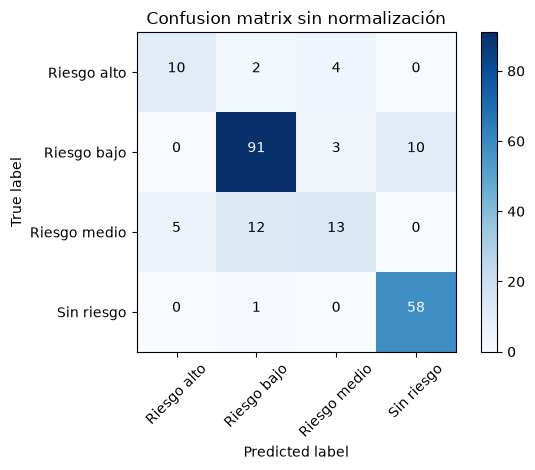

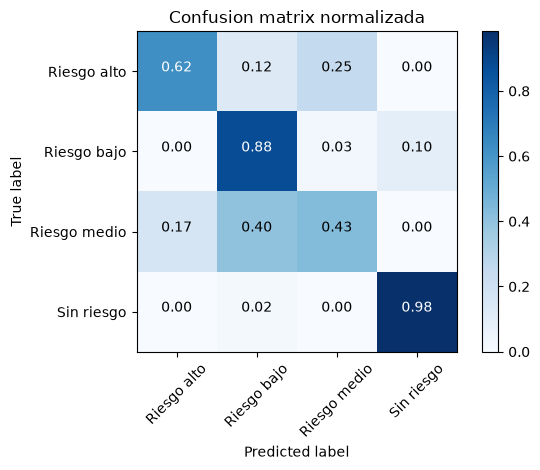

In [23]:
import itertools
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix sin normalizar')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

# Clases y predicciones
clases = le.classes_
y_pred = np.argmax(model.predict(X_test), axis=1)

cnf_matrix = confusion_matrix(y_test, y_pred)
np.set_printoptions(precision=2)

# Sin normalizar
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=clases,
                      title='Confusion matrix sin normalización')

# Normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=clases,
                      normalize=True,
                      title='Confusion matrix normalizada')
plt.show()

# Prediccion con nuevos datos

In [24]:
#Pediccion nuevos datos
# Tomamos los datos originales sin la columna objetivo
df_pred = df[df.columns.drop('risk_level')].copy()

# get_dummies igual que en entrenamiento
df_pred_dum = pd.get_dummies(df_pred, drop_first=True)
df_pred_dum = df_pred_dum.reindex(columns=X.columns, fill_value=0)

# Escalar
X_pred = scaler.transform(df_pred_dum)

# Predicción
y_prob_pred = model.predict(X_pred)
y_pred_clases = le.inverse_transform(np.argmax(y_prob_pred, axis=1))

# Unir predicción con datos originales
df_pred['PREDICCIÓN'] = y_pred_clases
df_pred

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,goout,Dalc,Walc,health,absences,G1,G2,subject,G3,PREDICCIÓN
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,1,1,3,6,5,6,math,6,Riesgo alto
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,1,1,3,4,5,5,math,6,Riesgo alto
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,2,2,3,3,10,7,8,math,10,Riesgo medio
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,1,1,5,2,15,14,math,15,Sin riesgo
4,GP,F,16,U,GT3,T,3,3,other,other,...,2,1,2,5,4,6,10,math,10,Riesgo bajo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039,MS,F,19,R,GT3,T,2,3,services,other,...,2,1,2,5,4,10,11,portuguese,10,Riesgo bajo
1040,MS,F,18,U,LE3,T,3,1,teacher,services,...,4,1,1,1,4,15,15,portuguese,16,Sin riesgo
1041,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,5,6,11,12,portuguese,9,Riesgo bajo
1042,MS,M,17,U,LE3,T,3,1,services,services,...,5,3,4,2,6,10,10,portuguese,10,Riesgo bajo


# Guardar y cargar el modelo

In [25]:
#Guardar y cargar el modelo para posterior uso
from tensorflow.keras.models import load_model
import pickle

# 1. Modelo
model.save('modelo_riesgo.keras')

# 2. Scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 3. LabelEncoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)